<a href="https://colab.research.google.com/github/lakShay3654/Machine-Learning/blob/main/rice_yield_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rice Yield Analysis and Machine Learning Models

This notebook analyzes rice yield, production, and harvested area data using **Linear**, **Polynomial**, and **Multivariate Regression** models.

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# 1. READ FAOSTAT DATA
df = pd.read_csv("rice.csv")

print("File loaded successfully!")
print("Original rows:", len(df))

File loaded successfully!
Original rows: 192


In [18]:
# 2. FILTER ONLY RICE
rice = df[df["Item"] == "Rice"].copy()
print("Rice rows:", len(rice))

Rice rows: 192


In [19]:
# 3. SEPARATE YIELD, PRODUCTION AND AREA
yield_data = (
    rice[rice["Element"] == "Yield"][["Year", "Value"]]
    .rename(columns={"Value": "Yield"})
)
production_data = (
    rice[rice["Element"] == "Production"][["Year", "Value"]]
    .rename(columns={"Value": "Production"})
)
area_data = (
    rice[rice["Element"] == "Area harvested"][["Year", "Value"]]
    .rename(columns={"Value": "Area"})
)

# 4. COMBINE AND CLEAN DATA
data = yield_data.merge(production_data, on="Year").merge(area_data, on="Year")
data = data.dropna().sort_values("Year").reset_index(drop=True)

print("\nFinal dataset preview:")
print(data.head())


Final dataset preview:
   Year   Yield  Production        Area
0  1961  1541.9  53494496.0  34694000.0
1  1962  1395.9  49825552.0  35695008.0
2  1963  1549.8  55497008.0  35809008.0
3  1964  1617.1  58962000.0  36462000.0
4  1965  1293.6  45883504.0  35470000.0


In [20]:
# 5. CHRONOLOGICAL TRAIN-TEST SPLIT (70% Train, 30% Test)
split_idx = int(len(data) * 0.70)

train = data.iloc[:split_idx].copy()
test = data.iloc[split_idx:].copy()

print(f"Training set: {len(train)} rows ({train['Year'].min()} - {train['Year'].max()})")
print(f"Testing set : {len(test)} rows ({test['Year'].min()} - {test['Year'].max()})\n")

Training set: 44 rows (1961 - 2004)
Testing set : 20 rows (2005 - 2024)



LINEAR REGRESSION RESULTS:
MSE : 73944.17607493048
RMSE: 271.92678440148273
MAE : 226.8732783650467
R2  : 0.5077594053598496


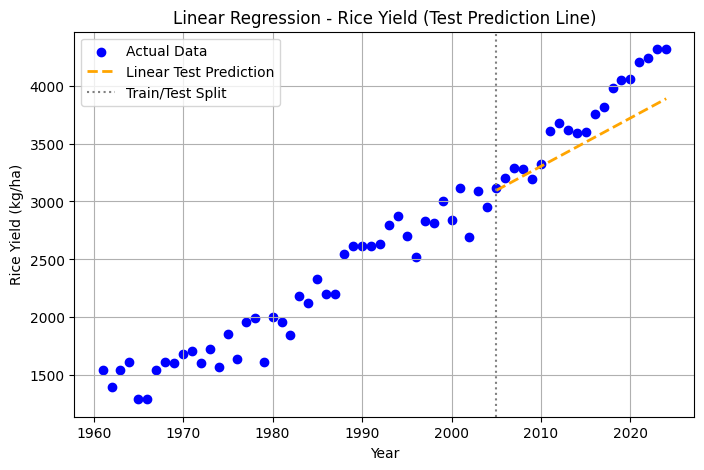

In [21]:
# 6. LINEAR REGRESSION
X_train = train[["Year"]]
y_train = train["Yield"]
X_test = test[["Year"]]
y_test = test["Yield"]

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("LINEAR REGRESSION RESULTS:")
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("MAE :", mae_linear)
print("R2  :", r2_linear)

plt.figure(figsize=(8, 5))
plt.scatter(data["Year"], data["Yield"], label="Actual Data", color="blue")
plt.plot(
    test["Year"],
    y_pred_linear,
    label="Linear Test Prediction",
    color="orange",
    linewidth=2,
    linestyle="--",
)
plt.axvline(x=test["Year"].min(), color="gray", linestyle=":", label="Train/Test Split")
plt.xlabel("Year")
plt.ylabel("Rice Yield (kg/ha)")
plt.title("Linear Regression - Rice Yield (Test Prediction Line)")
plt.legend()
plt.grid(True)
plt.show()



POLYNOMIAL REGRESSION RESULTS:
MSE : 8570.023392891211
RMSE: 92.5744208347598
MAE : 74.10751570083205
R2  : 0.9429500248035493


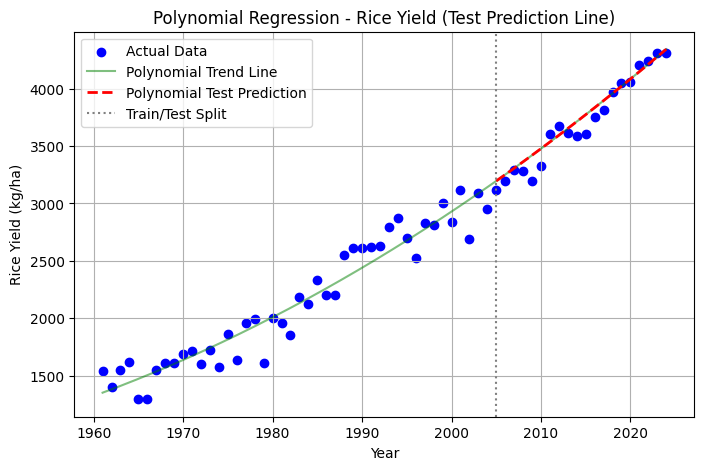

In [22]:
# 7. POLYNOMIAL REGRESSION
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("\nPOLYNOMIAL REGRESSION RESULTS:")
print("MSE :", mse_poly)
print("RMSE:", rmse_poly)
print("MAE :", mae_poly)
print("R2  :", r2_poly)

# Smooth curve for full trend + exact test prediction line
years_df = pd.DataFrame(
    {"Year": np.linspace(data["Year"].min(), data["Year"].max(), 200)}
)
years_poly = poly.transform(years_df)
predicted_yield_full = poly_model.predict(years_poly)

# Plot 2: Polynomial Regression with Test Line
plt.figure(figsize=(8, 5))
plt.scatter(data["Year"], data["Yield"], label="Actual Data", color="blue")
plt.plot(
    years_df["Year"],
    predicted_yield_full,
    label="Polynomial Trend Line",
    color="green",
    alpha=0.5,
)
plt.plot(
    test["Year"],
    y_pred_poly,
    label="Polynomial Test Prediction",
    color="red",
    linewidth=2,
    linestyle="--",
)
plt.axvline(x=test["Year"].min(), color="gray", linestyle=":", label="Train/Test Split")
plt.xlabel("Year")
plt.ylabel("Rice Yield (kg/ha)")
plt.title("Polynomial Regression - Rice Yield (Test Prediction Line)")
plt.legend()
plt.grid(True)
plt.show()



MULTIVARIATE REGRESSION RESULTS:
MSE : 20312.920219393895
RMSE: 142.52340235692486
MAE : 91.94377035134553
R2  : 0.8647784794093835


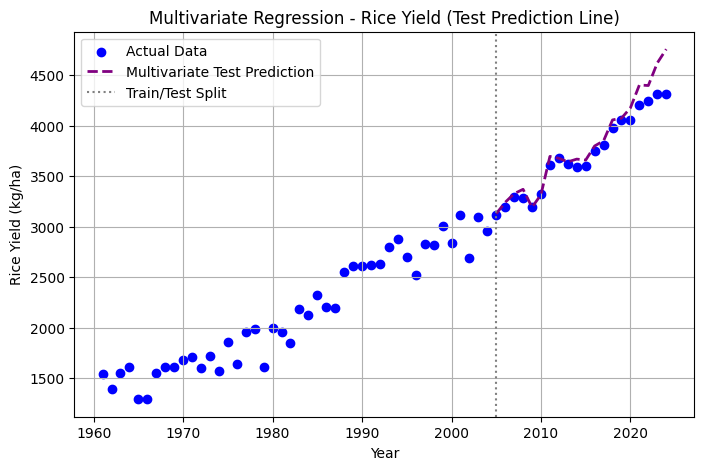

In [23]:
# 8. MULTIVARIATE REGRESSION
X_train_multi = train[["Year", "Production", "Area"]]
y_train_multi = train["Yield"]

X_test_multi = test[["Year", "Production", "Area"]]
y_test_multi = test["Yield"]

multi_model = LinearRegression()
multi_model.fit(X_train_multi, y_train_multi)

y_pred_multi = multi_model.predict(X_test_multi)

mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)

print("\nMULTIVARIATE REGRESSION RESULTS:")
print("MSE :", mse_multi)
print("RMSE:", rmse_multi)
print("MAE :", mae_multi)
print("R2  :", r2_multi)

# Plot 3: Multivariate Test Prediction vs Time Line
plt.figure(figsize=(8, 5))
plt.scatter(data["Year"], data["Yield"], label="Actual Data", color="blue")
plt.plot(
    test["Year"],
    y_pred_multi,
    label="Multivariate Test Prediction",
    color="purple",
    linewidth=2,
    linestyle="--",
)
plt.axvline(x=test["Year"].min(), color="gray", linestyle=":", label="Train/Test Split")
plt.xlabel("Year")
plt.ylabel("Rice Yield (kg/ha)")
plt.title("Multivariate Regression - Rice Yield (Test Prediction Line)")
plt.legend()
plt.grid(True)
plt.show()


In [24]:
# 9. MODEL COMPARISON & FUTURE PREDICTIONS (2030)
results = pd.DataFrame(
    {
        "Model": [
            "Linear Regression",
            "Polynomial Regression",
            "Multivariate Regression",
        ],
        "MSE": [mse_linear, mse_poly, mse_multi],
        "RMSE": [rmse_linear, rmse_poly, rmse_multi],
        "MAE": [mae_linear, mae_poly, mae_multi],
        "R2": [r2_linear, r2_poly, r2_multi],
    }
)

print("\n====================================")
print("MODEL COMPARISON (EVALUATED ON TEST SET)")
print("====================================")
print(results.to_string(index=False))

# Retrain on full historical data for 2030 forecast
full_linear = LinearRegression().fit(data[["Year"]], data["Yield"])
full_poly_X = poly.fit_transform(data[["Year"]])
full_poly = LinearRegression().fit(full_poly_X, data["Yield"])

future_year = 2030
future_df = pd.DataFrame([[future_year]], columns=["Year"])

future_prediction = full_linear.predict(future_df)[0]
future_prediction_poly = full_poly.predict(poly.transform(future_df))[0]

print("\n====================================")
print("FUTURE PREDICTION (2030)")
print("====================================")
print(f"Linear predicted rice yield for {future_year}: {future_prediction:.2f} kg/ha")
print(
    f"Polynomial predicted rice yield for {future_year}: {future_prediction_poly:.2f} kg/ha"
)


MODEL COMPARISON (EVALUATED ON TEST SET)
                  Model          MSE       RMSE        MAE       R2
      Linear Regression 73944.176075 271.926784 226.873278 0.507759
  Polynomial Regression  8570.023393  92.574421  74.107516 0.942950
Multivariate Regression 20312.920219 142.523402  91.943770 0.864778

FUTURE PREDICTION (2030)
Linear predicted rice yield for 2030: 4399.34 kg/ha
Polynomial predicted rice yield for 2030: 4714.54 kg/ha
